In [1]:
import os, json, math
from datetime import datetime, timedelta
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
load_dotenv()

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini")


In [2]:
categories = {
    "국내주식": 145, "해외주식": 120, "채권": 85,
    "섹터": 95, "원자재": 25, "부동산": 15, "기타": 30,
}

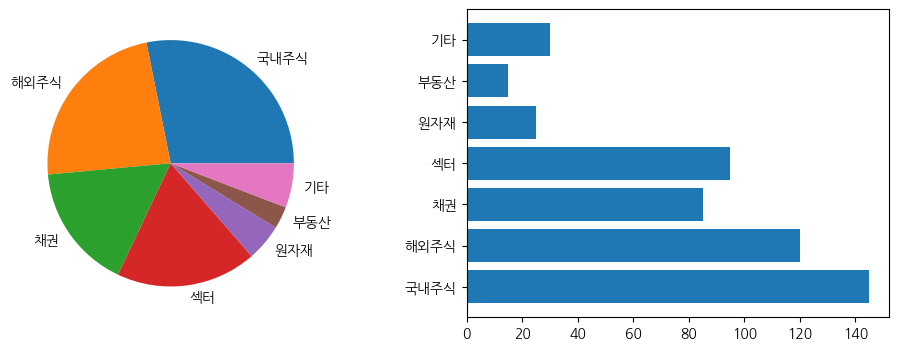

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.pie(categories.values(), labels = categories.keys(), )
ax2.barh(list(categories.keys()), list(categories.values()))

plt.show()

In [4]:
etf_universe = [
    {"name": "KODEX 200", "cat": "국내주식", "ret_1y": 12.3, "risk": 15.2},
    {"name": "TIGER S&P500", "cat": "해외주식", "ret_1y": 18.5, "risk": 13.8},
    {"name": "KODEX 배당가치", "cat": "배당", "ret_1y": 8.2, "risk": 10.5},
    {"name": "TIGER 반도체", "cat": "섹터", "ret_1y": 35.2, "risk": 28.4},
    {"name": "KODEX 국고채3년", "cat": "채권", "ret_1y": 3.5, "risk": 2.1},
    {"name": "KODEX 골드선물", "cat": "원자재", "ret_1y": 15.8, "risk": 16.3},
    {"name": "KODEX 2차전지", "cat": "섹터", "ret_1y": -5.2, "risk": 32.1},
    {"name": "TIGER 단기통안채", "cat": "채권", "ret_1y": 3.2, "risk": 0.8},
]


In [5]:
df_etf = pd.DataFrame(etf_universe)
df_etf

,name,cat,ret_1y,risk
0,KODEX 200,국내주식,12.3,15.2
1,TIGER S&P500,해외주식,18.5,13.8
2,KODEX 배당가치,배당,8.2,10.5
3,TIGER 반도체,섹터,35.2,28.4
4,KODEX 국고채3년,채권,3.5,2.1
5,KODEX 골드선물,원자재,15.8,16.3
6,KODEX 2차전지,섹터,-5.2,32.1
7,TIGER 단기통안채,채권,3.2,0.8


In [6]:
df_etf['cat'].unique()

array(['국내주식', '해외주식', '배당', '섹터', '채권', '원자재'], dtype=object)

In [7]:
for _, row in df_etf[df_etf['cat']=='채권'].iterrows():
    print(row)

name      KODEX 국고채3년
cat                채권
ret_1y            3.5
risk              2.1
Name: 4, dtype: object
name      TIGER 단기통안채
cat                채권
ret_1y            3.2
risk              0.8
Name: 7, dtype: object


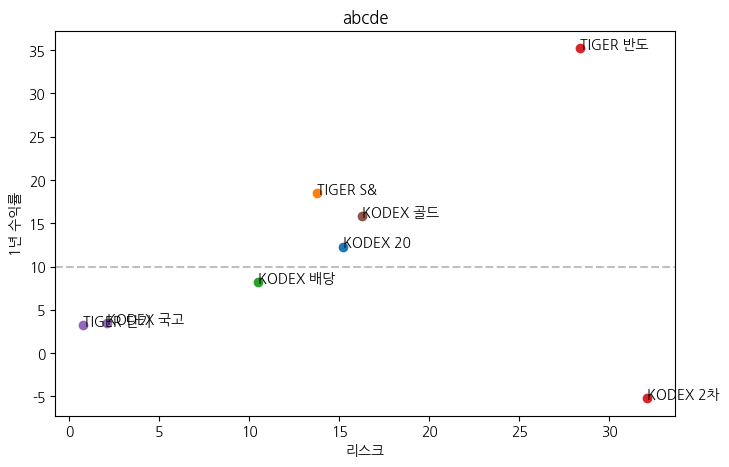

In [8]:
fig, ax = plt.subplots(figsize = (8,5))
for cat in df_etf['cat'].unique() :
    sub = df_etf[df_etf['cat']==cat]
    ax.scatter(sub['risk'], sub['ret_1y'], label = cat)
    for _, row in sub.iterrows():
        ax.annotate(row['name'][:8], (row['risk'], row['ret_1y']))

ax.set_xlabel('리스크')
ax.set_ylabel('1년 수익률')
ax.set_title('abcde')
ax.axhline(y=10, color='gray', linestyle='--', alpha=0.5)
plt.show()

In [9]:
# 데이터 스키마
# {"name": "KODEX 200", "cat": "국내주식", "ret_1y": 12.3, "risk": 15.2}
# {'국내 주식', "12.3%", 20 

# dataclass

In [10]:
@dataclass
class ETFSchema: # def __init__
    ticker : str  # 00233439
    name : str
    category : str
    expense_ratio : float
    risk_level : str = "중간"
    aum_billion : float = 0.0
    description : str = ""
    keywords : List[str] = field(default_factory=list)

    def __post_init__(self):
        if self.expense_ratio < 0 or self.expense_ratio > 5:
            raise ValueError(f"수수료 범위 오류: {self.expense_ratio}")
        valid_risks = ["매우낮음", "낮음", "중간", "높음", "매우높음"]
        if self.risk_level not in valid_risks:
            raise ValueError(f"리스크 등급 오류: {self.risk_level}")  # "매우 낮음"

In [11]:
etf = ETFSchema(
    ticker = "069500", name="KODEX 200", category="국내주식", expense_ratio=1.5, keywords = ['코스피', '대형주', '인덱스'])

In [12]:
etf

ETFSchema(ticker='069500', name='KODEX 200', category='국내주식', expense_ratio=1.5, risk_level='중간', aum_billion=0.0, description='', keywords=['코스피', '대형주', '인덱스'])

In [13]:
etf.ticker, etf.name, etf.expense_ratio

('069500', 'KODEX 200', 1.5)

In [14]:
etf_dict = asdict(etf)

In [15]:
etf_dict

{'ticker': '069500',
 'name': 'KODEX 200',
 'category': '국내주식',
 'expense_ratio': 1.5,
 'risk_level': '중간',
 'aum_billion': 0.0,
 'description': '',
 'keywords': ['코스피', '대형주', '인덱스']}

In [16]:
etf_json = json.dumps(etf_dict, ensure_ascii=False, indent=2)
etf_json

'{\n  "ticker": "069500",\n  "name": "KODEX 200",\n  "category": "국내주식",\n  "expense_ratio": 1.5,\n  "risk_level": "중간",\n  "aum_billion": 0.0,\n  "description": "",\n  "keywords": [\n    "코스피",\n    "대형주",\n    "인덱스"\n  ]\n}'

In [17]:
ETFSchema(**json.loads(etf_json))

ETFSchema(ticker='069500', name='KODEX 200', category='국내주식', expense_ratio=1.5, risk_level='중간', aum_billion=0.0, description='', keywords=['코스피', '대형주', '인덱스'])

In [18]:
test_cases = [
    {"ticker": "A", "name": "정상", "category": "채권",
     "expense_ratio": 0.05, "risk_level": "낮음"},
    {"ticker": "B", "name": "수수료오류", "category": "주식",
     "expense_ratio": -0.5, "risk_level": "중간"},
    {"ticker": "C", "name": "리스크오류", "category": "원자재",
     "expense_ratio": 0.3, "risk_level": "최고"},
]

In [19]:
for tc in test_cases:
    try:
        e = ETFSchema(**tc)
        print(f" {tc['name']}: 생성 성공")
    except ValueError as err:
        print(f" {tc['name']} : {err}")

 정상: 생성 성공
 수수료오류 : 수수료 범위 오류: -0.5
 리스크오류 : 리스크 등급 오류: 최고


In [20]:
# ETFReturns : 데이터 스키마
# __post_init__ 수익률 유효성 검증 (-100% ~ 500%)
# ticker : str
# return_1m : float
# return_3m : float
# return_1y : float
# return_3y : float

In [23]:
@dataclass
class ETFReturns:
    ticker : str
    return_1m : float
    return_3m : float
    return_1y : float
    return_3y : float

    def __post_init__(self):
        # if self.return_1m < -100 or self.return_1m > 500:
        #     raise ValueError(f"rate 범위 오류: {self.return_1m}")
        # if self.return_3m < -100 or self.return_3m > 500:
        #     raise ValueError(f"rate 범위 오류: {self.return_1m}")
        # if self.return_1y < -100 or self.return_1y > 500:
        #     raise ValueError(f"rate 범위 오류: {self.return_1m}")
        # if getattr(self, 'return_1m') < -100 or getattr(self, 'return_1m') > 500:  # self.return_1m
        #     raise ValueError(f"rate 범위 오류: {self.return_1m}")
        for field_name in ['return_1m', 'return_3m', 'return_1y', 'return_3y']:
            value = getattr(self, field_name)
            if value < -100 or value > 500:
                raise ValueError(f"{field_name} 오류: {value}")

In [24]:
# ETFReturns("123456", -200.1, 5.4, 12.3, 28.5)

In [25]:
# FinanceDataReader

In [26]:
# !pip install finance-datareader

In [27]:
# StockListing('ETF/KR')
# DataReader('123456', start, end)

In [28]:
import FinanceDataReader as fdr

In [29]:
etf_list = fdr.StockListing('ETF/KR')

In [30]:
len(etf_list)

1093

In [31]:
etf_list.head(3)

,Symbol,Category,Name,Price,RiseFall,Change,ChangeRate,NAV,EarningRate,Volume,Amount,MarCap
0,069500,1,KODEX 200,92665,2,2235,2.47,92539.0,31.5006,18643808,1742343,215214
1,360750,4,TIGER 미국S&P500,25515,2,185,0.73,25530.0,-0.4054,19344078,493402,157976
2,396500,2,TIGER 반도체TOP10,35490,2,890,2.57,35565.0,46.4860,21359114,763674,96054


In [32]:
ticker = "069500"
end_date = datetime.now().strftime('%Y-%m-%d')
start_date = (datetime.now() - timedelta(days=365)).strftime('%Y-%m-%d')

end_date, start_date

('2026-04-15', '2025-04-15')

In [33]:
price_df = fdr.DataReader(ticker, start_date, end_date)

In [34]:
len(price_df)

244

In [35]:
def collect_etf_price(ticker, days=365):
    end_date = datetime.now().strftime('%Y-%m-%d')
    start_date = (datetime.now() - timedelta(days=days)).strftime('%Y-%m-%d')

    try:
        df = fdr.DataReader(ticker, start_date, end_date)
        if len(df) > 0:
            return {'status' : 'real', 'data' : df, 'ticker' : ticker}
    except Exception:
        pass

In [36]:
tickers = ['069500']
collect_etf_price(tickers[0])

{'status': 'real',
 'data':              Open   High    Low  Close    Volume    Change
 Date                                                      
 2025-04-15  32417  32781  32417  32692   8915848  0.009854
 2025-04-16  32556  32614  32169  32183   7177604 -0.015570
 2025-04-17  32271  32561  32203  32501   6951765  0.009881
 2025-04-18  32556  32722  32452  32722   6025639  0.006800
 2025-04-21  32727  32918  32634  32766   5020620  0.001345
 ...           ...    ...    ...    ...       ...       ...
 2026-04-09  88310  88735  87070  87250  20553049 -0.019663
 2026-04-10  88795  89805  88520  88655  12112242  0.016103
 2026-04-13  86465  88090  86410  87880  13658534 -0.008742
 2026-04-14  90245  91600  89955  90430  17031936  0.029017
 2026-04-15  93405  94180  92205  92665  18643808  0.024715
 
 [244 rows x 6 columns],
 'ticker': '069500'}

In [37]:
# 결측치 처리, 이상치 처리

In [38]:
# # 주말, 휴장일, : row 전체가 결측치  / row 일부가 결측치
# 1. 무시 : 결측치 있는 값을 지워버린다
# 2. 채운다 : 

In [39]:
# 4/14 : 32570
# 4/15 :  채워준다. : interpolation : 평균 / 이전일 또는 이후일의 값 / rolling-average
# 4/16 : 32614

In [40]:
# outlier , anomaly , 이상치
# IQR : anomaly detect -> 지워버리거나 / 

In [41]:
sample_df = price_df.copy()

In [42]:
mask = np.random.random(len(sample_df)) < 0.05

In [43]:
sample_df.loc[mask, 'Close'] = np.nan

In [44]:
sample_df['Close'].isna().sum()

np.int64(11)

In [45]:
len(sample_df)

244

In [46]:
ffill_df = sample_df.copy()
ffill_df['Close'] = ffill_df['Close'].ffill()

In [47]:
ffill_df['Close'].isna().sum()

np.int64(0)

In [48]:
interp_df = sample_df.copy()
interp_df['Close'].isna().sum()

np.int64(11)

In [49]:
interp_df['Close'] = interp_df['Close'].interpolate(method='linear')

In [50]:
interp_df['Close'].isna().sum()

np.int64(0)

In [52]:
rolling_df = sample_df.copy()
rolling_mean = rolling_df['Close'].rolling(5, min_periods=1).mean()
rolling_mean
rolling_df['Close'] = rolling_df['Close'].fillna(rolling_mean)

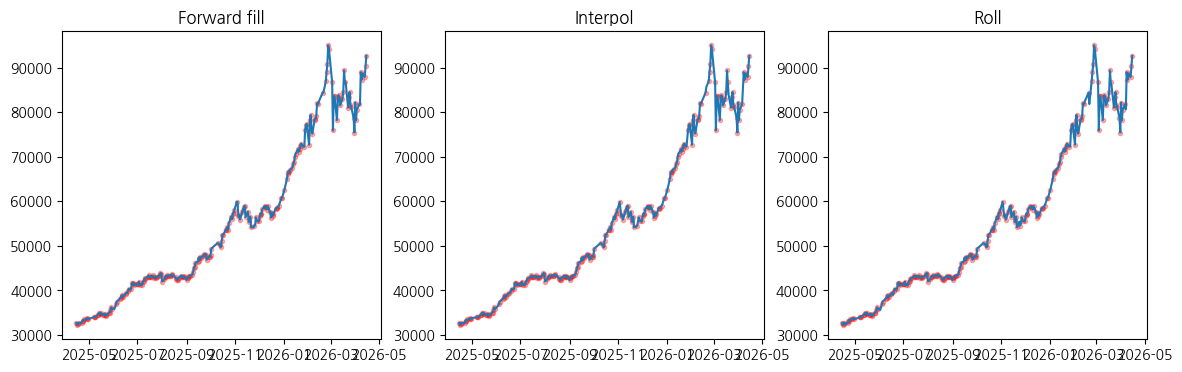

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, df_filled, title in zip(axes, [ffill_df,interp_df, rolling_df], ['Forward fill', 'Interpol', 'Roll']):
    ax.plot(sample_df.index, sample_df['Close'], 'ro', markersize=3, alpha=0.3, label='missing')
    ax.plot(df_filled.index, df_filled['Close'], label=title)
    ax.set_title(title)
plt.show()

In [54]:
def detect_iqr(series, factor=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return (series < q1 - factor * iqr) | (series > q3 + factor * iqr)

def detect_z(series, threshold=3.0):
    z = (series - series.mean()) / series.std()
    return z.abs() > threshold


z_outliers = detect_z(ffill_df)
z_outliers.sum()

Open      0
High      0
Low       0
Close     0
Volume    3
Change    7
dtype: int64

In [55]:
iqr_outliers = detect_iqr(ffill_df)
iqr_outliers.sum()

Open       0
High       0
Low        0
Close      0
Volume    10
Change    23
dtype: int64

In [56]:
(z_outliers & iqr_outliers).sum()

Open      0
High      0
Low       0
Close     0
Volume    3
Change    7
dtype: int64

In [57]:
ffill_df.head()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2025-04-15,32417,32781,32417,32692.0,8915848,0.009854
2025-04-16,32556,32614,32169,32183.0,7177604,-0.015570
2025-04-17,32271,32561,32203,32501.0,6951765,0.009881
2025-04-18,32556,32722,32452,32722.0,6025639,0.006800
2025-04-21,32727,32918,32634,32722.0,5020620,0.001345


In [58]:
features = ffill_df[['Close']].copy()

In [59]:
features

,Close
Date,
2025-04-15,32692.0
2025-04-16,32183.0
2025-04-17,32501.0
2025-04-18,32722.0
2025-04-21,32722.0
...,...
2026-04-09,87250.0
2026-04-10,88655.0
2026-04-13,87880.0


In [60]:
features['return'] = features['Close'].pct_change()

In [61]:
features.head()

,Close,return
Date,,
2025-04-15,32692.0,NaN
2025-04-16,32183.0,-0.015570
2025-04-17,32501.0,0.009881
2025-04-18,32722.0,0.006800
2025-04-21,32722.0,0.000000


In [62]:
features['vol_5d'] = features['return'].rolling(5).std()
features['vol_20d'] = features['return'].rolling(20).std()

In [63]:
features.head()

,Close,return,vol_5d,vol_20d
Date,,,,
2025-04-15,32692.0,NaN,NaN,NaN
2025-04-16,32183.0,-0.015570,NaN,NaN
2025-04-17,32501.0,0.009881,NaN,NaN
2025-04-18,32722.0,0.006800,NaN,NaN
2025-04-21,32722.0,0.000000,NaN,NaN


In [64]:
features['log_return'] = np.log(features['Close'] / features['Close'].shift(1))

In [65]:
def preprocess_pipeline(df):
    result = df[['Close']].copy()

    #1. 결측값을 처리 (linear- interpolation)
    result['Close'] = result['Close'].interpolate(method='linear')
    result['Close'] = result['Close'].ffill().bfill()

    #2. 이상치를 ffill (IQR * 1.5)
    ret = result['Close']
    q1, q3 = ret.quantile(0.25), ret.quantile(0.75)
    iqr = q3 - q1
    outlier_mask  = (ret < q1 - 1.5 * iqr) | (ret > q3 + 1.5 * iqr)
    result.loc[outlier_mask, 'Close'] = np.nan
    result['Close'] = result['Close'].ffill()

    #3. feature 추가 (return, log_return)
    result['return'] = result['Close'].pct_change()
    result['log_return'] = np.log(features['Close'] / features['Close'].shift(1))

    return result
    

In [66]:
processed = preprocess_pipeline(price_df)

In [67]:
processed.head()

,Close,return,log_return
Date,,,
2025-04-15,32692.0,NaN,NaN
2025-04-16,32183.0,-0.015570,-0.015692
2025-04-17,32501.0,0.009881,0.009832
2025-04-18,32722.0,0.006800,0.006777
2025-04-21,32766.0,0.001345,0.000000


In [68]:
# 이동평균, 트렌드 분해(decomposition), 이상 탐지, 분포 분석
# 서버 트래픽, 이커머스 구매내역, 센서 데이터, 온도,,,,,

In [69]:
# 이동평균 : 노이즈
# S(standard)MA : 최근 N개의 평균
# E(exponential)MA : 최근 값에 더 큰 가중치를 두는 MA

In [71]:
# 트렌드 분해(decomposition)
# 트렌드 : 장기적으로 매출이 상승하고 있다. 전반적으로 시니어 타겟의 시장이 커지고 있다.
# Seasonality (주기) : 여름에는 잘팔리고, 겨울에는 안팔린다
# Residual (잔차) : 나머지

In [74]:
# !pip install statsmodels

In [72]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [112]:
ffill_df.head()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2025-04-15,32417,32781,32417,32692.0,8915848,0.009854
2025-04-16,32556,32614,32169,32183.0,7177604,-0.015570
2025-04-17,32271,32561,32203,32501.0,6951765,0.009881
2025-04-18,32556,32722,32452,32722.0,6025639,0.006800
2025-04-21,32727,32918,32634,32722.0,5020620,0.001345


In [75]:
close = ffill_df['Close']
close

Date
2025-04-15    32692.0
2025-04-16    32183.0
2025-04-17    32501.0
2025-04-18    32722.0
2025-04-21    32722.0
               ...   
2026-04-09    87250.0
2026-04-10    88655.0
2026-04-13    87880.0
2026-04-14    90430.0
2026-04-15    92665.0
Name: Close, Length: 244, dtype: float64

In [76]:
sma_20 = close.rolling(20).mean()
ema_20 = close.ewm(span=20).mean() 

In [77]:
weekly = close.resample('W').last().dropna()
decomp = seasonal_decompose(weekly, model = 'additive', period=13)

In [82]:
# decomp.seasonal

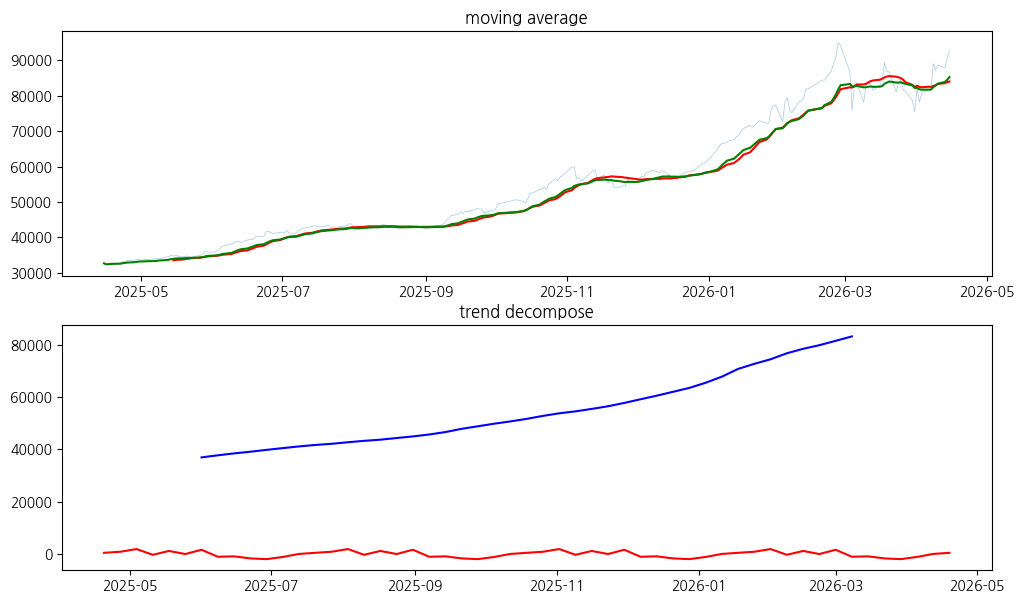

In [85]:
fig, axes = plt.subplots(2, 1, figsize = (12, 7))
ax = axes[0]
ax.plot(close.index, close, alpha=0.4, linewidth=0.5, label='original')
ax.plot(sma_20.index, sma_20, linewidth=1.5, label = 'sma', color='red')
ax.plot(ema_20.index, ema_20, linewidth=1.5, label = 'ema', color='green')
ax.set_title('moving average')

weekly = close.resample('W').last().dropna()
decomp = seasonal_decompose(weekly, model = 'additive', period=13)
axes[1].plot(decomp.trend.index, decomp.trend, label='trend', linewidth=1.5, color= 'blue')
axes[1].plot(decomp.seasonal.index, decomp.seasonal, label='seasonal', linewidth=1.5, color='red')
axes[1].set_title('trend decompose')

plt.show()

In [86]:
# time-series data : trend + seasonality + (residual)
#                    trend * seasonality + (residual)

In [87]:
tickers = {
    '069500': 'KODEX 200 (국내주식)',
    '360750': 'TIGER S&P500 (미국주식)',
    '152380': 'KODEX 국고채10년 (채권)',
    '132030': 'KODEX 골드선물 (원자재)',
}


In [89]:
multi_close = pd.DataFrame()
for ticker, name in tickers.items():
    df = fdr.DataReader(ticker, start=(datetime.now() - timedelta(days=365)).strftime('%Y-%m-%d'))
    multi_close[name] = df['Close']

In [90]:
multi_close.head()

,KODEX 200 (국내주식),TIGER S&P500 (미국주식),KODEX 국고채10년 (채권),KODEX 골드선물 (원자재)
Date,,,,
2025-04-15,32692,18972,70736,19189
2025-04-16,32183,18720,70899,19582
2025-04-17,32501,18616,70860,19806
2025-04-18,32722,18621,70993,19851
2025-04-21,32766,18334,71127,20135


In [91]:
multi_close = multi_close.dropna()

In [92]:
returns = multi_close.pct_change().dropna()

In [93]:
returns.head()

,KODEX 200 (국내주식),TIGER S&P500 (미국주식),KODEX 국고채10년 (채권),KODEX 골드선물 (원자재)
Date,,,,
2025-04-16,-0.015570,-0.013283,0.002304,0.020480
2025-04-17,0.009881,-0.005556,-0.000550,0.011439
2025-04-18,0.006800,0.000269,0.001877,0.002272
2025-04-21,0.001345,-0.015413,0.001888,0.014307
2025-04-22,-0.003296,-0.009436,-0.001111,0.028408


In [94]:
cum_returns = (1 + returns).cumprod()


In [95]:
cum_returns.head()

,KODEX 200 (국내주식),TIGER S&P500 (미국주식),KODEX 국고채10년 (채권),KODEX 골드선물 (원자재)
Date,,,,
2025-04-16,0.984430,0.986717,1.002304,1.020480
2025-04-17,0.994158,0.981236,1.001753,1.032154
2025-04-18,1.000918,0.981499,1.003633,1.034499
2025-04-21,1.002264,0.966371,1.005528,1.049299
2025-04-22,0.998960,0.957253,1.004411,1.079108


In [96]:
cum_returns.tail()

,KODEX 200 (국내주식),TIGER S&P500 (미국주식),KODEX 국고채10년 (채권),KODEX 골드선물 (원자재)
Date,,,,
2026-04-09,2.668849,1.314042,0.950718,1.397415
2026-04-10,2.711826,1.323266,0.948880,1.408359
2026-04-13,2.688119,1.321157,0.946477,1.400281
2026-04-14,2.766120,1.335125,0.951566,1.410965
2026-04-15,2.834486,1.344877,0.952980,1.426077


In [97]:
cum_returns.columns

Index(['KODEX 200 (국내주식)', 'TIGER S&P500 (미국주식)', 'KODEX 국고채10년 (채권)',
       'KODEX 골드선물 (원자재)'],
      dtype='object')

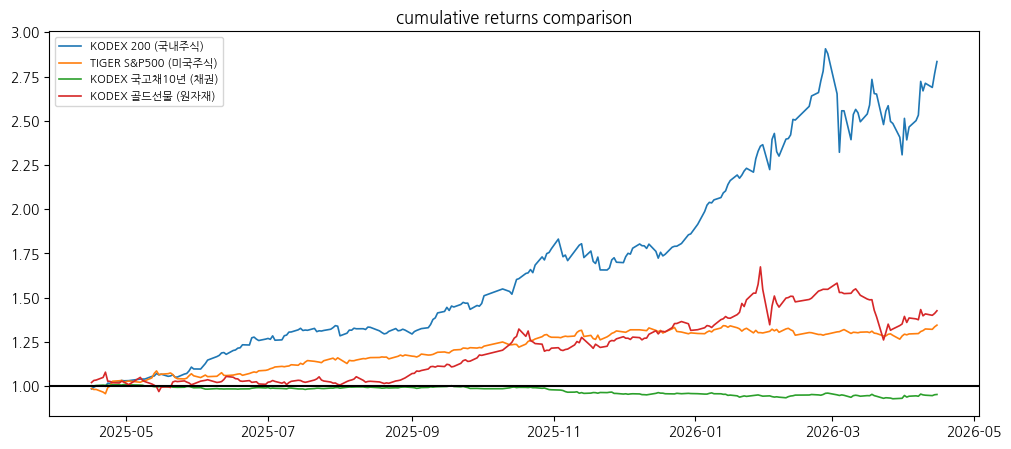

In [99]:
fig, ax = plt.subplots(figsize =  (12, 5))
for col in cum_returns.columns:
    ax.plot(cum_returns.index, cum_returns[col], label=col, linewidth = 1.2)

ax.axhline(1.0, color='black')
ax.legend(fontsize=8)
ax.set_title('cumulative returns comparison')
plt.show()

In [ ]:
# pearson correlation (피어슨 상관관계)

In [103]:
corr_matrix = returns.corr()

In [104]:
corr_matrix

,KODEX 200 (국내주식),TIGER S&P500 (미국주식),KODEX 국고채10년 (채권),KODEX 골드선물 (원자재)
KODEX 200 (국내주식),1.000000,0.293541,0.389003,0.383096
TIGER S&P500 (미국주식),0.293541,1.000000,0.031366,-0.068603
KODEX 국고채10년 (채권),0.389003,0.031366,1.000000,0.165718
KODEX 골드선물 (원자재),0.383096,-0.068603,0.165718,1.000000


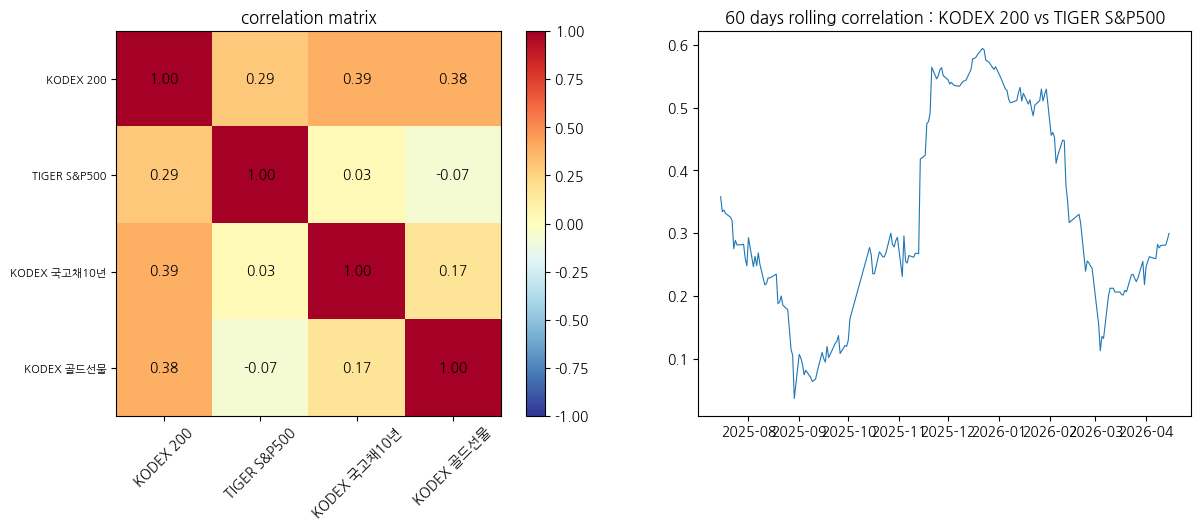

In [111]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
im = ax1.imshow(corr_matrix, cmap='RdYlBu_r', vmin=-1, vmax=1)  # 히트맵
ax1.set_xticks(range(len(corr_matrix)))
ax1.set_yticks(range(len(corr_matrix)))
short_names = [c.split('(')[0].strip() for c in corr_matrix.columns]
ax1.set_xticklabels(short_names, rotation=45)
ax1.set_yticklabels(short_names, fontsize=8)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax1.text(j, i, f'{corr_matrix.iloc[i,j]:.2f}', fontsize=10, ha='center', va='center')
fig.colorbar(im, ax= ax1)
ax1.set_title('correlation matrix')

cols = returns.columns.tolist()
if len(cols) >=2:
    rolling_corr = returns[cols[0]].rolling(60).corr(returns[cols[1]])
    ax2.plot(rolling_corr.index, rolling_corr, linewidth=0.8)
    ax2.set_title(f'60 days rolling correlation : {short_names[0]} vs {short_names[1]}')

plt.show()

In [113]:
def calculate_metrics(returns_series, risk_free = 0.035): # 수익률, 변동성, MDD, 샤프
    ann_ret = (1 + returns_series.mean()) ** 252 - 1
    ann_vol = returns_series.std() * np.sqrt(252)
    sharpe = (ann_ret - risk_free) / ann_vol
    
    cum = (1 + returns_series).cumprod()
    mdd = ((cum - cum.cummax()) / cum.cummax()).min()
    
    return {
        'yearly return' : f'{ann_ret* 100 :.1f}%',
        'yearly volatile' : f'{ann_vol* 100 :.1f}%',
        'MDD' : f'{mdd * 100:.1f}%',
        'sharpe' : f'{sharpe:.1f}'
    }

In [114]:
metrics_rows = []
for col in returns.columns:
    m = calculate_metrics(returns[col])
    m['ETF'] = col.split('(')[0].strip()
    metrics_rows.append(m)

In [115]:
metrics_rows

[{'yearly return': '215.0%',
  'yearly volatile': '36.6%',
  'MDD': '-20.6%',
  'sharpe': '5.8',
  'ETF': 'KODEX 200'},
 {'yearly return': '37.2%',
  'yearly volatile': '13.3%',
  'MDD': '-5.7%',
  'sharpe': '2.5',
  'ETF': 'TIGER S&P500'},
 {'yearly return': '-4.7%',
  'yearly volatile': '5.7%',
  'MDD': '-8.0%',
  'sharpe': '-1.4',
  'ETF': 'KODEX 국고채10년'},
 {'yearly return': '51.8%',
  'yearly volatile': '31.1%',
  'MDD': '-24.7%',
  'sharpe': '1.6',
  'ETF': 'KODEX 골드선물'}]

In [116]:
metrics_df = pd.DataFrame(metrics_rows)
metrics_df

,yearly return,yearly volatile,MDD,sharpe,ETF
0,215.0%,36.6%,-20.6%,5.8,KODEX 200
1,37.2%,13.3%,-5.7%,2.5,TIGER S&P500
2,-4.7%,5.7%,-8.0%,-1.4,KODEX 국고채10년
3,51.8%,31.1%,-24.7%,1.6,KODEX 골드선물


In [117]:
metrics_df = pd.DataFrame(metrics_rows).set_index('ETF')
metrics_df

,yearly return,yearly volatile,MDD,sharpe
ETF,,,,
KODEX 200,215.0%,36.6%,-20.6%,5.8
TIGER S&P500,37.2%,13.3%,-5.7%,2.5
KODEX 국고채10년,-4.7%,5.7%,-8.0%,-1.4
KODEX 골드선물,51.8%,31.1%,-24.7%,1.6


In [118]:
print(metrics_df)

             yearly return yearly volatile     MDD sharpe
ETF                                                      
KODEX 200           215.0%           36.6%  -20.6%    5.8
TIGER S&P500         37.2%           13.3%   -5.7%    2.5
KODEX 국고채10년         -4.7%            5.7%   -8.0%   -1.4
KODEX 골드선물           51.8%           31.1%  -24.7%    1.6


In [119]:
metrics_df.to_string()

'             yearly return yearly volatile     MDD sharpe\nETF                                                      \nKODEX 200           215.0%           36.6%  -20.6%    5.8\nTIGER S&P500         37.2%           13.3%   -5.7%    2.5\nKODEX 국고채10년         -4.7%            5.7%   -8.0%   -1.4\nKODEX 골드선물           51.8%           31.1%  -24.7%    1.6'

In [ ]:
# 금융챗봇 
# 1. 데이터 수집, 전처리
# 2. 데이터 분석 
# ---------------------- raw data
# 3. 데이터 만들기        : RAG --> 사용자 쿼리 : RAG 성능 평가를 위한 데이터 생성
# 4. RAG 구현

In [120]:
def generate_analysis_insight(metrics_df):
    response = ChatOpenAI(model = 'gpt-4o-mini', temperature=0.3, max_tokens=400).invoke([
        {'role' : 'system', 'content' : '당신은 금융 데이터 분석가입니다. 수치 기반으로 직관적인 인사이트를 제공합니다'},
        {'role' : 'user', 'content' : f"""아래 ETF 비교 데이터를 분석하여 투자 인사이트를 작성하세요.
        
        {metrics_df.to_string()}
        
        다음 형식으로 답하세요:
        1. 핵심 발견(3줄)
        2. 위험 요인(2줄)
        3. 분산 투자 제안(2줄)"""}
    ])
    return response.content

In [121]:
insight = generate_analysis_insight(metrics_df)


'1. 핵심 발견: KODEX 200은 가장 높은 연간 수익률(215.0%)과 샤프 비율(5.8)을 기록하여 투자자에게 매력적인 선택으로 보입니다. TIGER S&P500은 안정적인 수익률(37.2%)과 낮은 변동성을 제공하여 리스크를 줄이는 데 유리합니다. KODEX 골드선물은 높은 수익률(51.8%)을 보였지만, 변동성이 크고 MDD가 높아 주의가 필요합니다.\n\n2. 위험 요인: KODEX 200의 높은 수익률은 높은 변동성과 함께 나타나며, 이는 투자자에게 큰 손실 위험을 동반할 수 있습니다. KODEX 국고채10년은 부정적인 수익률을 기록하여 안전 자산으로서의 역할이 제한적입니다.\n\n3. 분산 투자 제안: KODEX 200과 TIGER S&P500을 조합하여 높은 수익률과 안정성을 동시에 추구하는 전략이 유효할 것입니다. 또한, KODEX 골드선물에 소액 투자하여 포트폴리오의 다각화를 도모하는 것도 좋은 접근법입니다.'

In [122]:
print(insight)

1. 핵심 발견: KODEX 200은 가장 높은 연간 수익률(215.0%)과 샤프 비율(5.8)을 기록하여 투자자에게 매력적인 선택으로 보입니다. TIGER S&P500은 안정적인 수익률(37.2%)과 낮은 변동성을 제공하여 리스크를 줄이는 데 유리합니다. KODEX 골드선물은 높은 수익률(51.8%)을 보였지만, 변동성이 크고 MDD가 높아 주의가 필요합니다.

2. 위험 요인: KODEX 200의 높은 수익률은 높은 변동성과 함께 나타나며, 이는 투자자에게 큰 손실 위험을 동반할 수 있습니다. KODEX 국고채10년은 부정적인 수익률을 기록하여 안전 자산으로서의 역할이 제한적입니다.

3. 분산 투자 제안: KODEX 200과 TIGER S&P500을 조합하여 높은 수익률과 안정성을 동시에 추구하는 전략이 유효할 것입니다. 또한, KODEX 골드선물에 소액 투자하여 포트폴리오의 다각화를 도모하는 것도 좋은 접근법입니다.


In [126]:
# !pip install scipy

In [127]:
def generate_analysis_report(ticker_name, close_prices):
    
    returns = close_prices.pct_change().dropna()
    sma_20 = close_prices.rolling(20).mean().iloc[-1]
    sma_60 = close_prices.rolling(60).mean().iloc[-1]
    current = close_prices.iloc[-1]
    
    roll_mean = returns.rolling(30).mean()
    roll_std = returns.rolling(30).std()
    z_latest = ((returns - roll_mean) / roll_std).iloc[-1]
    
    from scipy.stats import skew, kurtosis
    
    sk = skew(returns.dropna())
    kt = kurtosis(returns.dropna())
    
    vol_recent = returns[-20:].std() * np.sqrt(252) * 100
    vol_overall = returns.std() * np.sqrt(252) * 100
    
    indicators = {
        '현재가': f'{current:,.0f}',
        'SMA(20)': f'{sma_20:,.0f}',
        'SMA(60)': f'{sma_60:,.0f}',
        '추세': '상승' if sma_20 > sma_60 else '하락',
        '최근 롤링 Z-score': f'{z_latest:.2f}',
        '이상 여부': '정상' if abs(z_latest) < 2 else '주의' if abs(z_latest) < 3 else '이상',
        'Skewness': f'{sk:.3f}',
        'Kurtosis': f'{kt:.3f}',
        '최근 20일 변동성': f'{vol_recent:.1f}%',
        '전체 변동성': f'{vol_overall:.1f}%',
        '변동성 변화': '확대' if vol_recent > vol_overall else '축소',
    }
    
    response = ChatOpenAI(model = 'gpt-4o-mini', temperature=0.5, max_tokens=400).invoke([
        {'role' : 'system', 'content' : '당신은 데이터 분석가입니다. 수치에 근거해서 분석하세요'},
        {'role' : 'user', 'content' : f"""이 시계열 분석 지표를 바탕으로 {ticker_name}의 현재 상태를 2~3문장으로 요약해주세요
         
         {json.dumps(indicators, ensure_ascii=False, indent=2)}
         
         투자 추천은 하지 마세요. 객관적 현황만 서술해주세요."""}
    ])
    
    
    return response.content
    

In [128]:
generate_analysis_report('KODEX 200', close)

'KODEX 200의 현재가는 92,665으로, 최근 20일 이동평균(SMA 20)인 83,990과 비교해 상승세를 보이고 있습니다. 최근 롤링 Z-score가 0.40으로 정상 범위에 있으며, 변동성은 64.7%로 증가하고 있어 시장의 불안정성이 커지고 있는 상황입니다. Skewness가 -0.469로 왼쪽으로 치우쳐 있고, Kurtosis가 6.422로 높은 수치를 기록하여 분포의 꼬리가 두드러진 상태입니다.'

In [129]:
def generate_analysis_report_llm_only(ticker_name, close_prices):
    recent_prices = close_prices.tail(120).tolist()
    
    prompt = f"""
    다음은 {ticker_name}의 종가 데이터입니다.
    
    {recent_prices}
    
    이 데이터를 기반으로 
    - 추세 (상승/하락/횡보)
    - 변동성 특징
    - 최근 이상 움직임 여부
    
    를 판단하고 2~3문장으로 요약하세요.
    
    수치 계산은 직접 수행해서 근거 기반으로 설명하세요.
    투자 추천은 하지 마세요. 객관적 현황만 서술해주세요."""
    
    response = ChatOpenAI(model = 'gpt-4o-mini', temperature=0.5, max_tokens=400).invoke([
        {'role' : 'system', 'content' : '당신은 데이터 분석가입니다. 수치에 근거해서 분석하세요'},
        {'role' : 'user', 'content' : prompt}
    ])
    
    return response.content


generate_analysis_report_llm_only('KODEX 200', close)

'KODEX 200의 종가 데이터를 분석한 결과, 전반적으로 상승 추세를 보였습니다. 1월 초의 종가 53626.0에서 시작하여 92665.0까지 약 73% 상승하였으며, 특히 2023년 1월부터 9월까지의 상승폭이 두드러집니다. \n\n변동성을 측정하기 위해 표준편차를 계산해보면, 종가의 평균은 약 78689.7이고, 표준편차는 약 13182.1로 나타났습니다. 이는 가격이 평균에 비해 상당한 변동성을 보임을 의미합니다.\n\n최근 3개월 간의 데이터에서 89000.0에서 92665.0으로의 상승은 약 4%의 증가율을 보였으며, 이는 상대적으로 안정적인 상승세로 판단됩니다. 그러나 89000.0에서 86750.0으로의 하락이 있었던 점은 주의할 필요가 있습니다. 전반적으로는 상승세가 지속되고 있지만, 변동성이 큰 점을 감안해야 합니다.'

In [130]:
kodex = fdr.DataReader('069500', start=(datetime.now() - timedelta(days=180)).strftime('%Y-%m-%d'))
tiger = fdr.DataReader('360750', start=(datetime.now() - timedelta(days=180)).strftime('%Y-%m-%d'))
bond = fdr.DataReader('152380', start=(datetime.now() - timedelta(days=180)).strftime('%Y-%m-%d'))

In [131]:
kodex.head()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2025-10-17,52177,53263,52067,52550,15786206,0.002863
2025-10-20,53004,53531,52182,53511,13861376,0.018287
2025-10-21,53995,54757,53477,53626,16980847,0.002149
2025-10-22,53457,54239,52949,54234,15661565,0.011338
2025-10-23,53432,54558,53263,53661,13552170,-0.010565


In [132]:
tiger.head()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2025-10-17,23186,23241,23137,23157,6759909,-0.012284
2025-10-20,23425,23505,23415,23480,3422634,0.013948
2025-10-21,23703,23783,23664,23773,6054153,0.012479
2025-10-22,23833,23888,23783,23868,3658566,0.003996
2025-10-23,23723,23923,23674,23888,3978269,0.000838


In [133]:
bond.head()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2025-10-17,70276,70419,70217,70266,3946,0.001482
2025-10-20,70167,70291,70162,70246,10153,-0.000285
2025-10-21,70330,70345,70143,70172,4593,-0.001053
2025-10-22,70157,70326,70157,70326,13726,0.002195
2025-10-23,70405,70449,70113,70113,2854,-0.003029


In [139]:
combined = pd.concat([
    kodex['Close'],tiger['Close'],bond['Close']
], axis=1)

combined.head()

,Close,Close,Close
Date,,,
2025-10-17,52550,23157,70266
2025-10-20,53511,23480,70246
2025-10-21,53626,23773,70172
2025-10-22,54234,23868,70326
2025-10-23,53661,23888,70113


In [140]:
combined = pd.concat([
    kodex['Close'].rename('kodex_close'),tiger['Close'].rename('tiger_close'),bond['Close'].rename('bond_close')
], axis=1)

combined.head()

,kodex_close,tiger_close,bond_close
Date,,,
2025-10-17,52550,23157,70266
2025-10-20,53511,23480,70246
2025-10-21,53626,23773,70172
2025-10-22,54234,23868,70326
2025-10-23,53661,23888,70113


In [152]:
meta = pd.DataFrame([
    {'ticker': '069500', 'name': 'KODEX 200', 'category': '국내주식', 'expense': 0.15},
    {'ticker': '360750', 'name': 'TIGER S&P500', 'category': '해외주식', 'expense': 0.07},
    {'ticker': '152380', 'name': 'KODEX 국고채10년', 'category': '채권', 'expense': 0.05},
    {'ticker': '132030', 'name': 'KODEX 골드선물', 'category': '원자재', 'expense': 0.68},
])

In [153]:
meta.head()

,ticker,name,category,expense
0,069500,KODEX 200,국내주식,0.15
1,360750,TIGER S&P500,해외주식,0.07
2,152380,KODEX 국고채10년,채권,0.05
3,132030,KODEX 골드선물,원자재,0.68


In [154]:
analysis = pd.DataFrame([
    {'ticker': '069500', 'sharpe': 0.82, 'mdd': -0.15},
    {'ticker': '360750', 'sharpe': 1.25, 'mdd': -0.12},
    {'ticker': '152380', 'sharpe': 0.31, 'mdd': -0.05},
    {'ticker': '132030', 'sharpe': 0.95, 'mdd': -0.08},
])

analysis.head()

,ticker,sharpe,mdd
0,069500,0.82,-0.15
1,360750,1.25,-0.12
2,152380,0.31,-0.05
3,132030,0.95,-0.08


In [157]:
# inner join   : 교집합
# outer join   : 합집합
# left join    : meta
# right join   : analysis

In [156]:
merged = pd.merge(meta, analysis, on='ticker', how = 'inner')
merged.head()

,ticker,name,category,expense,sharpe,mdd
0,069500,KODEX 200,국내주식,0.15,0.82,-0.15
1,360750,TIGER S&P500,해외주식,0.07,1.25,-0.12
2,152380,KODEX 국고채10년,채권,0.05,0.31,-0.05
3,132030,KODEX 골드선물,원자재,0.68,0.95,-0.08


In [158]:
df_a = kodex['Close'].rename('A')
df_a

Date
2025-10-17    52550
2025-10-20    53511
2025-10-21    53626
2025-10-22    54234
2025-10-23    53661
              ...  
2026-04-09    87250
2026-04-10    88655
2026-04-13    87880
2026-04-14    90430
2026-04-15    92665
Name: A, Length: 122, dtype: int64

In [159]:
df_b = tiger['Close'].rename('B')
df_b

Date
2025-10-17    23157
2025-10-20    23480
2025-10-21    23773
2025-10-22    23868
2025-10-23    23888
              ...  
2026-04-09    24930
2026-04-10    25105
2026-04-13    25065
2026-04-14    25330
2026-04-15    25515
Name: B, Length: 122, dtype: int64

In [162]:
np.random.seed(42)
drop_idx = np.random.choice(df_b.index, size=5, replace=False)
df_b_missing = df_b.drop(drop_idx)

In [163]:
df_b_missing

Date
2025-10-17    23157
2025-10-20    23480
2025-10-21    23773
2025-10-22    23868
2025-10-24    24027
              ...  
2026-04-09    24930
2026-04-10    25105
2026-04-13    25065
2026-04-14    25330
2026-04-15    25515
Name: B, Length: 117, dtype: int64

In [164]:
inner = pd.concat([df_a, df_b_missing], axis=1).dropna()
inner

,A,B
Date,,
2025-10-17,52550,23157.0
2025-10-20,53511,23480.0
2025-10-21,53626,23773.0
2025-10-22,54234,23868.0
2025-10-24,55062,24027.0
...,...,...
2026-04-09,87250,24930.0
2026-04-10,88655,25105.0
2026-04-13,87880,25065.0


In [165]:
alinged = df_b_missing.reindex(df_a.index).ffill()

In [167]:
outer = pd.concat([df_a, alinged.rename('B_aligned')], axis=1)
outer.head()

,A,B_aligned
Date,,
2025-10-17,52550,23157.0
2025-10-20,53511,23480.0
2025-10-21,53626,23773.0
2025-10-22,54234,23868.0
2025-10-23,53661,23868.0


In [168]:
price_dict = {
    '069500': kodex,
    '360750': tiger,
    '152380': bond,
}

In [171]:
def merge_all(price_dict, meta_df):
    
    #1. price_dict 에 있는 ticker 들의 close 들
    closes = pd.concat({ticker : df['Close'] for ticker, df in price_dict.items()}, axis=1).dropna()
    
    #2. price_dict 에 있는 close들의 annual return
    analysis_rows = []
    for ticker in closes.columns:
        ret = closes[ticker].pct_change().dropna()
        ann_ret = (1 + ret.mean()) ** 255 - 1
        analysis_rows.append({
            'ticker' : ticker,
            'annual_return' : round(ann_ret * 100, 2)
        })
    analysis_df = pd.DataFrame(analysis_rows)
    #3. 1,2를 merge 한 dataframe 
    
    result = pd.merge(meta_df, analysis_df, on='ticker', how='inner')
    
    return result

In [172]:
price_dict = {
    '069500': kodex,
    '360750': tiger,
    '152380': bond,
}

result = merge_all(price_dict, meta)
result

,ticker,name,category,expense,annual_return
0,069500,KODEX 200,국내주식,0.15,272.43
1,360750,TIGER S&P500,해외주식,0.07,23.75
2,152380,KODEX 국고채10년,채권,0.05,-8.14


In [ ]:
# pivot table, filter
# groupby, pivot_table

In [173]:
long_data = []
for ticker, name in [('069500', 'KODEX200'), ('360750', 'TIGER_SP500'), ('152380', 'KODEX_국고채')]:
    df = price_dict.get(ticker)
    if df is None:
        continue
    ret = df['Close'].pct_change().dropna()
    for date, val in ret.items():
        long_data.append({
            'date': date,
            'ticker': ticker,
            'name': name,
            'return': val,
            'weekday': date.strftime('%a'),
            'month': date.month,
        })
long_df = pd.DataFrame(long_data)
print(f"Long format: {long_df.shape}")


Long format: (363, 6)


In [174]:
long_df.head()

,date,ticker,name,return,weekday,month
0,2025-10-20,069500,KODEX200,0.018287,Mon,10
1,2025-10-21,069500,KODEX200,0.002149,Tue,10
2,2025-10-22,069500,KODEX200,0.011338,Wed,10
3,2025-10-23,069500,KODEX200,-0.010565,Thu,10
4,2025-10-24,069500,KODEX200,0.026108,Fri,10


In [175]:
long_df.tail()

,date,ticker,name,return,weekday,month
358,2026-04-09,152380,KODEX_국고채,-0.004662,Thu,4
359,2026-04-10,152380,KODEX_국고채,-0.001933,Fri,4
360,2026-04-13,152380,KODEX_국고채,-0.002533,Mon,4
361,2026-04-14,152380,KODEX_국고채,0.005377,Tue,4
362,2026-04-15,152380,KODEX_국고채,0.001486,Wed,4


In [179]:
summary = long_df.groupby('name')['return'].agg(
    평균수익률 = 'mean',
    변동성 = 'std', 
    최대 = 'max',
    최소 = 'min',
    거래일수 = 'count'
)
summary

,평균수익률,변동성,최대,최소,거래일수
name,,,,,
KODEX200,0.005170,0.030692,0.101054,-0.124618,121
KODEX_국고채,-0.000333,0.004464,0.017152,-0.012295,121
TIGER_SP500,0.000836,0.008290,0.018928,-0.026759,121


In [181]:
summary['평균수익률'] = (summary['평균수익률'] * 100 ).round(4)

In [182]:
summary

,평균수익률,변동성,최대,최소,거래일수
name,,,,,
KODEX200,0.5170,0.030692,0.101054,-0.124618,121
KODEX_국고채,-0.0333,0.004464,0.017152,-0.012295,121
TIGER_SP500,0.0836,0.008290,0.018928,-0.026759,121


In [183]:
long_df.head()

,date,ticker,name,return,weekday,month
0,2025-10-20,069500,KODEX200,0.018287,Mon,10
1,2025-10-21,069500,KODEX200,0.002149,Tue,10
2,2025-10-22,069500,KODEX200,0.011338,Wed,10
3,2025-10-23,069500,KODEX200,-0.010565,Thu,10
4,2025-10-24,069500,KODEX200,0.026108,Fri,10


In [184]:
pd.pivot_table(long_df, values ='return', index='name', columns='month', aggfunc='mean')

month,1,2,3,4,10,11,12
name,,,,,,,
KODEX200,0.011545,0.012140,-0.009222,0.019562,0.010145,-0.001922,0.004390
KODEX_국고채,-0.000733,0.001072,-0.001459,0.002117,-0.001392,-0.001065,-0.000026
TIGER_SP500,0.000011,-0.000227,-0.000399,0.004286,0.004504,0.001442,-0.000375


In [185]:
vol_pivot = pd.pivot_table(long_df, values='return', index='name', columns='month', aggfunc='std')

In [186]:
vol_pivot

month,1,2,3,4,10,11,12
name,,,,,,,
KODEX200,0.011950,0.032510,0.051126,0.039064,0.013681,0.023680,0.013825
KODEX_국고채,0.003706,0.003513,0.005920,0.007791,0.002383,0.003578,0.002856
TIGER_SP500,0.007987,0.008705,0.007879,0.004493,0.007038,0.011211,0.007453


In [187]:
stacked = vol_pivot.stack()
stacked

name         month
KODEX200     1        0.011950
             2        0.032510
             3        0.051126
             4        0.039064
             10       0.013681
             11       0.023680
             12       0.013825
KODEX_국고채    1        0.003706
             2        0.003513
             3        0.005920
             4        0.007791
             10       0.002383
             11       0.003578
             12       0.002856
TIGER_SP500  1        0.007987
             2        0.008705
             3        0.007879
             4        0.004493
             10       0.007038
             11       0.011211
             12       0.007453
dtype: float64

In [188]:
stacked.idxmax()

('KODEX200', np.int64(3))

In [189]:
stacked.max()

np.float64(0.05112596631250477)